In [ ]:
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
import numpy as np
import xarray as xr
import rioxarray
from rasterio.transform import from_origin
from rasterio.enums import Resampling

import plotly.graph_objects as go
import ipywidgets as widgets
from IPython.display import display, clear_output

from toposhapes_sar import (
    RotatedEllipsoid,
    RotatedCuboid,
    RotatedTrapezoidalPrism,
    apply_shape,
)



In [9]:

# =============================================================================
# 1. INPUT FILES
# =============================================================================

DATA_DIR = Path("../data")

DEM_PATH = DATA_DIR / "P.dem"
PAR_PATH = DATA_DIR / "P.dem_par"

assert DEM_PATH.exists(), f"Missing DEM: {DEM_PATH}"
assert PAR_PATH.exists(), f"Missing DEM parameter file: {PAR_PATH}"

print("[SETUP] Input files")
print("        DEM:    ", DEM_PATH.resolve())
print("        DEM par:", PAR_PATH.resolve())



[SETUP] Input files
        DEM:     /Users/elioteaton/Documents/git_repos/toposhapes_sar_dem/data/P.dem
        DEM par: /Users/elioteaton/Documents/git_repos/toposhapes_sar_dem/data/P.dem_par


In [10]:

# =============================================================================
# 2. READ GAMMA DEM PARAMETER FILE
# =============================================================================

def read_gamma_dem_par(path):
    """
    Parse the small subset of GAMMA DEM parameter metadata needed here.
    """

    values = {}

    with open(path, "r") as f:

        for line in f:

            if ":" not in line:
                continue

            key, value = line.split(":", 1)

            key = key.strip()
            value = value.strip()

            if not value:
                continue

            # First token is sufficient for the numeric fields we need.
            token = value.split()[0]

            values[key] = token

    required = [
        "data_format",
        "width",
        "nlines",
        "corner_lat",
        "corner_lon",
        "post_lat",
        "post_lon",
    ]

    for key in required:
        if key not in values:
            raise ValueError(
                f"Required GAMMA parameter '{key}' not found in {path}"
            )

    return {
        "data_format": values["data_format"],
        "width": int(values["width"]),
        "nlines": int(values["nlines"]),
        "corner_lat": float(values["corner_lat"]),
        "corner_lon": float(values["corner_lon"]),
        "post_lat": float(values["post_lat"]),
        "post_lon": float(values["post_lon"]),
        "projection": values.get("DEM_projection", None),
        "ellipsoid": values.get("ellipsoid_name", None),
        "datum": values.get("datum_name", None),
    }


meta = read_gamma_dem_par(PAR_PATH)

print("\n[SETUP] Parsed GAMMA metadata")

for key, value in meta.items():
    print(f"        {key}: {value}")

if meta["data_format"] != "REAL*4":
    raise ValueError(
        f"Expected GAMMA REAL*4, got {meta['data_format']}"
    )




[SETUP] Parsed GAMMA metadata
        data_format: REAL*4
        width: 4089
        nlines: 3497
        corner_lat: 3.2336112
        corner_lon: 98.3266666
        post_lat: -3.4722223e-05
        post_lon: 3.4722223e-05
        projection: EQA
        ellipsoid: WGS
        datum: WGS


In [11]:

# =============================================================================
# 3. READ ORIGINAL GAMMA BINARY
# =============================================================================

width = meta["width"]
nlines = meta["nlines"]

expected_bytes = width * nlines * 4

actual_bytes = DEM_PATH.stat().st_size

print("\n[CHECK] GAMMA binary size")
print("        expected:", expected_bytes)
print("        actual:  ", actual_bytes)

if actual_bytes != expected_bytes:
    raise ValueError(
        "P.dem file size does not match width * nlines * 4."
    )

# GAMMA source DEM is big-endian REAL*4
dem_values = np.fromfile(
    DEM_PATH,
    dtype=">f4",
).reshape(
    nlines,
    width,
)

# Convert to native float32 for numerical processing.
dem_values = dem_values.astype(
    np.float32,
    copy=False,
)

print("\n[CHECK] Original DEM")
print("        shape:", dem_values.shape)
print("        dtype:", dem_values.dtype)
print(
    "        elevation range:",
    float(np.nanmin(dem_values)),
    "to",
    float(np.nanmax(dem_values)),
    "m",
)




[CHECK] GAMMA binary size
        expected: 57196932
        actual:   57196932

[CHECK] Original DEM
        shape: (3497, 4089)
        dtype: float32
        elevation range: 681.786865234375 to 2425.986572265625 m


In [12]:

# =============================================================================
# 4. CREATE AUTHORITATIVE GEOGRAPHIC XARRAY
# =============================================================================

corner_lat = meta["corner_lat"]
corner_lon = meta["corner_lon"]

post_lat = meta["post_lat"]
post_lon = meta["post_lon"]

# GAMMA corner_lat/lon are pixel-centre coordinates.
x_geo = (
    corner_lon
    + np.arange(width) * post_lon
)

y_geo = (
    corner_lat
    + np.arange(nlines) * post_lat
)

dem_geo_original = xr.DataArray(
    dem_values,
    dims=("y", "x"),
    coords={
        "x": x_geo,
        "y": y_geo,
    },
    name="elevation",
)

dem_geo_original = (
    dem_geo_original
    .rio.write_crs("EPSG:4326")
)

west = (
    corner_lon
    - post_lon / 2.0
)

north = (
    corner_lat
    - post_lat / 2.0
)

geo_transform = from_origin(
    west,
    north,
    post_lon,
    abs(post_lat),
)

dem_geo_original = (
    dem_geo_original
    .rio.write_transform(
        geo_transform
    )
)

print("\n[CHECK] Geographic DEM")
print("        CRS:", dem_geo_original.rio.crs)
print("        shape:", dem_geo_original.shape)
print("        resolution:", dem_geo_original.rio.resolution())
print("        bounds:", dem_geo_original.rio.bounds())


# =============================================================================
# 5. PROJECT TO METRES
# =============================================================================

projected_crs = (
    dem_geo_original
    .rio
    .estimate_utm_crs()
)

print("\n[SETUP] Projecting DEM")
print("        projected CRS:", projected_crs)
print("        resampling: nearest neighbour")

dem_m_original = (
    dem_geo_original
    .rio
    .reproject(
        projected_crs,
        resampling=Resampling.nearest,
        nodata=np.nan,
    )
)

print("\n[CHECK] Projected DEM")
print("        shape:", dem_m_original.shape)
print("        CRS:", dem_m_original.rio.crs)
print("        resolution:", dem_m_original.rio.resolution())
print("        bounds:", dem_m_original.rio.bounds())





[CHECK] Geographic DEM
        CRS: EPSG:4326
        shape: (3497, 4089)
        resolution: (3.4722223e-05, -3.4722223e-05)
        bounds: (98.32664923888849, 3.1122049472805, 98.4686284087355, 3.2336285611115)

[SETUP] Projecting DEM
        projected CRS: EPSG:32647
        resampling: nearest neighbour

[CHECK] Projected DEM
        shape: (3489, 4100)
        CRS: EPSG:32647
        resolution: (3.849666191002757, -3.849666191002757)
        bounds: (425180.9650070674, 344010.2339726222, 440964.5963901788, 357441.71931303083)


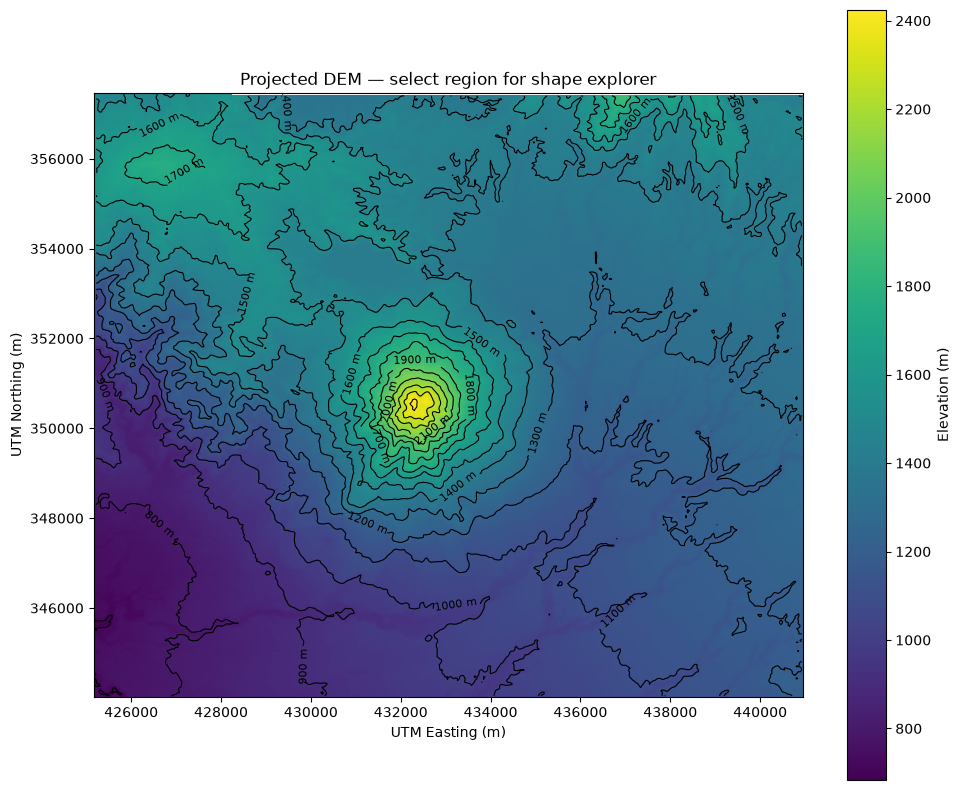

In [13]:
# Downsample ONLY for quick plotting.
# This does not modify dem_m_original.
plot_step = 10

dem_plot = dem_m_original.isel(
    x=slice(None, None, plot_step),
    y=slice(None, None, plot_step),
)


fig, ax = plt.subplots(
    figsize=(10, 8)
)

# DEM
dem_plot.plot.pcolormesh(
    ax=ax,
    x="x",
    y="y",
    shading="auto",
    cbar_kwargs={
        "label": "Elevation (m)"
    },
)


# 100 m contour levels
zmin = float(
    np.floor(dem_plot.min() / 100) * 100
)

zmax = float(
    np.ceil(dem_plot.max() / 100) * 100
)

levels = np.arange(
    zmin,
    zmax + 100,
    100,
)


# Black contours
contours = dem_plot.plot.contour(
    ax=ax,
    x="x",
    y="y",
    levels=levels,
    colors="black",
    linewidths=0.8,
    add_colorbar=False,
)


# Label contour elevations
ax.clabel(
    contours,
    inline=True,
    fontsize=8,
    fmt="%d m",
)


ax.set_title(
    "Projected DEM — select region for shape explorer"
)

ax.set_xlabel(
    "UTM Easting (m)"
)

ax.set_ylabel(
    "UTM Northing (m)"
)

ax.set_aspect("equal")

plt.tight_layout()
plt.show()

In [14]:
# =============================================================================
# CHOOSE INTERACTIVE VIEW REGION
# =============================================================================

USE_MANUAL_VIEW = True

if USE_MANUAL_VIEW:

    VIEW_X = [431500, 433000]
    VIEW_Y = [350000, 352000]

else:

    # Default window centred on projected DEM
    x0 = float(
        dem_m_original.x.values[
            len(dem_m_original.x) // 2
        ]
    )

    y0 = float(
        dem_m_original.y.values[
            len(dem_m_original.y) // 2
        ]
    )

    VIEW_RADIUS_M = 500.0

    VIEW_X = [
        x0 - VIEW_RADIUS_M,
        x0 + VIEW_RADIUS_M,
    ]

    VIEW_Y = [
        y0 - VIEW_RADIUS_M,
        y0 + VIEW_RADIUS_M,
    ]


# Centre of selected window
VIEW_X_CENTRE = np.mean(VIEW_X)
VIEW_Y_CENTRE = np.mean(VIEW_Y)


# Crop DEM
# Note: y coordinates are descending
dem_view_original = dem_m_original.sel(
    x=slice(
        VIEW_X[0],
        VIEW_X[1],
    ),
    y=slice(
        VIEW_Y[1],
        VIEW_Y[0],
    ),
)


print("\n[SETUP] Interactive DEM crop")

print(
    f"        x = {VIEW_X[0]:.1f} to {VIEW_X[1]:.1f} m"
)

print(
    f"        y = {VIEW_Y[0]:.1f} to {VIEW_Y[1]:.1f} m"
)

print(
    f"        centre = "
    f"({VIEW_X_CENTRE:.1f}, {VIEW_Y_CENTRE:.1f})"
)

print(
    f"        shape = {dem_view_original.shape}"
)




[SETUP] Interactive DEM crop
        x = 431500.0 to 433000.0 m
        y = 350000.0 to 352000.0 m
        centre = (432250.0, 351000.0)
        shape = (519, 390)


In [15]:
# =============================================================================
# 7. INITIAL FIXED Z
# =============================================================================

reference_surface_z = float(
    dem_m_original.sel(
        x=VIEW_X_CENTRE,
        y=VIEW_Y_CENTRE,
        method="nearest",
    )
)


INITIAL_Z = reference_surface_z

print("\n[SETUP] Initial shape z")
print("        local DEM surface:", INITIAL_Z, "m")




[SETUP] Initial shape z
        local DEM surface: 2162.232177734375 m


In [ ]:
# =============================================================================
# 8. INTERACTIVE SHAPE EXPLORER
# =============================================================================

import numpy as np
import plotly.graph_objects as go
from plotly.subplots import make_subplots

import ipywidgets as widgets
from IPython.display import display, clear_output

from toposhapes_sar import (
    RotatedEllipsoid,
    RotatedCuboid,
    RotatedTrapezoidalPrism,
    apply_shape,
)


# =============================================================================
# 8.1 COMMON CONTROLS
# =============================================================================

shape_dropdown = widgets.Dropdown(
    options=[
        "ellipsoid",
        "cuboid",
        "trapezoid",
    ],
    value="ellipsoid",
    description="Shape",
)


interaction_dropdown = widgets.Dropdown(
    options=[
        "fill_to_upper",
        "excavate_to_lower",
        "add_thickness",
        "subtract_thickness",
    ],
    value="fill_to_upper",
    description="Interaction",
)


display_dropdown = widgets.Dropdown(
    options=[
        "modified DEM",
        "original DEM",
        "difference",
    ],
    value="modified DEM",
    description="Surface",
)


# =============================================================================
# 8.2 POSITION CONTROLS
# =============================================================================

x_slider = widgets.FloatSlider(
    value=VIEW_X_CENTRE,
    min=VIEW_X[0],
    max=VIEW_X[1],
    step=5.0,
    description="x (m)",
    continuous_update=False,
)

y_slider = widgets.FloatSlider(
    value=VIEW_Y_CENTRE,
    min=VIEW_Y[0],
    max=VIEW_Y[1],
    step=5.0,
    description="y (m)",
    continuous_update=False,
)

z_slider = widgets.FloatSlider(
    value=INITIAL_Z,
    min=INITIAL_Z - 500.0,
    max=INITIAL_Z + 500.0,
    step=5.0,
    description="z (m)",
    continuous_update=False,
)


# =============================================================================
# 8.3 ROTATION CONTROLS
# =============================================================================

yaw_slider = widgets.FloatSlider(
    value=0.0,
    min=0.0,
    max=360.0,
    step=5.0,
    description="yaw",
    continuous_update=False,
)

pitch_slider = widgets.FloatSlider(
    value=0.0,
    min=-90.0,
    max=90.0,
    step=5.0,
    description="pitch",
    continuous_update=False,
)

roll_slider = widgets.FloatSlider(
    value=0.0,
    min=-90.0,
    max=90.0,
    step=5.0,
    description="roll",
    continuous_update=False,
)


# =============================================================================
# 8.4 ELLIPSOID CONTROLS
# =============================================================================

ellipsoid_a = widgets.FloatSlider(
    value=75.0,
    min=10.0,
    max=300.0,
    step=5.0,
    description="a",
    continuous_update=False,
)

ellipsoid_b = widgets.FloatSlider(
    value=50.0,
    min=10.0,
    max=300.0,
    step=5.0,
    description="b",
    continuous_update=False,
)

ellipsoid_c = widgets.FloatSlider(
    value=50.0,
    min=10.0,
    max=300.0,
    step=5.0,
    description="c",
    continuous_update=False,
)


# =============================================================================
# 8.5 CUBOID CONTROLS
# =============================================================================

cuboid_length = widgets.FloatSlider(
    value=150.0,
    min=10.0,
    max=400.0,
    step=5.0,
    description="length",
    continuous_update=False,
)

cuboid_width = widgets.FloatSlider(
    value=100.0,
    min=10.0,
    max=400.0,
    step=5.0,
    description="width",
    continuous_update=False,
)

cuboid_height = widgets.FloatSlider(
    value=100.0,
    min=10.0,
    max=400.0,
    step=5.0,
    description="height",
    continuous_update=False,
)


# =============================================================================
# 8.6 TRAPEZOID CONTROLS
# =============================================================================

trap_bottom = widgets.FloatSlider(
    value=150.0,
    min=10.0,
    max=400.0,
    step=5.0,
    description="bottom L",
    continuous_update=False,
)

trap_top = widgets.FloatSlider(
    value=75.0,
    min=10.0,
    max=400.0,
    step=5.0,
    description="top L",
    continuous_update=False,
)

trap_width = widgets.FloatSlider(
    value=100.0,
    min=10.0,
    max=400.0,
    step=5.0,
    description="width",
    continuous_update=False,
)

trap_height = widgets.FloatSlider(
    value=80.0,
    min=10.0,
    max=400.0,
    step=5.0,
    description="height",
    continuous_update=False,
)


# Container whose contents change with shape type
geometry_controls = widgets.VBox()


# =============================================================================
# 8.7 SHAPE-SPECIFIC CONTROL DISPLAY
# =============================================================================

def update_geometry_controls(change=None):

    shape_type = shape_dropdown.value

    if shape_type == "ellipsoid":

        geometry_controls.children = [
            widgets.HTML(
                "<b>Ellipsoid semi-axes (m)</b>"
            ),
            ellipsoid_a,
            ellipsoid_b,
            ellipsoid_c,
        ]

    elif shape_type == "cuboid":

        geometry_controls.children = [
            widgets.HTML(
                "<b>Cuboid full dimensions (m)</b>"
            ),
            cuboid_length,
            cuboid_width,
            cuboid_height,
        ]

    elif shape_type == "trapezoid":

        geometry_controls.children = [
            widgets.HTML(
                "<b>Trapezoidal prism dimensions (m)</b>"
            ),
            trap_bottom,
            trap_top,
            trap_width,
            trap_height,
        ]


shape_dropdown.observe(
    update_geometry_controls,
    names="value",
)

update_geometry_controls()


# =============================================================================
# 8.8 SHAPE FACTORY
# =============================================================================

def make_current_shape():

    center = (
        float(x_slider.value),
        float(y_slider.value),
        float(z_slider.value),
    )

    rotation = (
        float(yaw_slider.value),
        float(pitch_slider.value),
        float(roll_slider.value),
    )

    shape_type = shape_dropdown.value

    if shape_type == "ellipsoid":

        return RotatedEllipsoid(
            center=center,
            semi_axes=(
                float(ellipsoid_a.value),
                float(ellipsoid_b.value),
                float(ellipsoid_c.value),
            ),
            rotation_deg=rotation,
        )

    elif shape_type == "cuboid":

        return RotatedCuboid(
            center=center,
            size=(
                float(cuboid_length.value),
                float(cuboid_width.value),
                float(cuboid_height.value),
            ),
            rotation_deg=rotation,
        )

    elif shape_type == "trapezoid":

        return RotatedTrapezoidalPrism(
            center=center,
            bottom_length=float(
                trap_bottom.value
            ),
            top_length=float(
                trap_top.value
            ),
            width=float(
                trap_width.value
            ),
            height=float(
                trap_height.value
            ),
            rotation_deg=rotation,
        )

    raise ValueError(
        f"Unknown shape type: {shape_type}"
    )


# =============================================================================
# 8.9 PROFILE EXTRACTION
# =============================================================================

def extract_profiles(
    dem_original,
    dem_modified,
    x0,
    y0,
):
    """
    Extract east-west and north-south profiles through
    the grid cell nearest the geometry centre.
    """

    original_x = dem_original.sel(
        y=y0,
        method="nearest",
    )

    modified_x = dem_modified.sel(
        y=y0,
        method="nearest",
    )

    original_y = dem_original.sel(
        x=x0,
        method="nearest",
    )

    modified_y = dem_modified.sel(
        x=x0,
        method="nearest",
    )

    return {
        "ew_x": original_x.x.values,
        "ew_original": original_x.values,
        "ew_modified": modified_x.values,

        "ns_y": original_y.y.values,
        "ns_original": original_y.values,
        "ns_modified": modified_y.values,
    }


# =============================================================================
# 8.10 OUTPUT AREA
# =============================================================================

output = widgets.Output()


# =============================================================================
# 8.11 MAIN UPDATE FUNCTION
# =============================================================================

def refresh(change=None):

    shape = make_current_shape()

    interaction = (
        interaction_dropdown.value
    )

    shape_x = float(
        x_slider.value
    )

    shape_y = float(
        y_slider.value
    )

    shape_z = float(
        z_slider.value
    )

    # -------------------------------------------------------------------------
    # Apply geometry
    # -------------------------------------------------------------------------

    dem_modified, dz = apply_shape(
        dem_view_original,
        shape,
        interaction=interaction,
    )

    dz_values = dz.values

    changed = (
        np.isfinite(dz_values)
        & (dz_values != 0)
    )

    changed_pixels = int(
        np.count_nonzero(
            changed
        )
    )

    # -------------------------------------------------------------------------
    # Volume diagnostics
    # -------------------------------------------------------------------------

    dx, dy = (
        dem_view_original
        .rio
        .resolution()
    )

    pixel_area_m2 = abs(
        dx * dy
    )

    added_volume_m3 = max(
        0.0,
        float(
            np.nansum(
                np.where(
                    dz_values > 0,
                    dz_values,
                    0.0,
                )
            )
            * pixel_area_m2
        ),
    )

    removed_volume_m3 = max(
        0.0,
        float(
            -np.nansum(
                np.where(
                    dz_values < 0,
                    dz_values,
                    0.0,
                )
            )
            * pixel_area_m2
        ),
    )

    net_volume_m3 = float(
        np.nansum(
            dz_values
        )
        * pixel_area_m2
    )

    # -------------------------------------------------------------------------
    # Surface to show
    # -------------------------------------------------------------------------

    display_mode = (
        display_dropdown.value
    )

    if display_mode == "original DEM":

        surface = (
            dem_view_original.values
        )

        surface_title = (
            "Original DEM"
        )

        colour_title = (
            "Elevation (m)"
        )

    elif display_mode == "difference":

        surface = dz.values

        surface_title = (
            "DEM difference"
        )

        colour_title = (
            "Δz (m)"
        )

    else:

        surface = (
            dem_modified.values
        )

        surface_title = (
            "Modified DEM"
        )

        colour_title = (
            "Elevation (m)"
        )

    # -------------------------------------------------------------------------
    # Profiles
    # -------------------------------------------------------------------------

    profiles = extract_profiles(
        dem_view_original,
        dem_modified,
        shape_x,
        shape_y,
    )

    # Convert coordinates to distance relative to shape centre.
    #
    # This makes profile interpretation easier.
    ew_distance = (
        profiles["ew_x"]
        - shape_x
    )

    ns_distance = (
        profiles["ns_y"]
        - shape_y
    )

    # -------------------------------------------------------------------------
    # Figure layout
    #
    # Large 3-D DEM on left.
    # East-west and north-south profiles on right.
    # -------------------------------------------------------------------------

    fig = make_subplots(
        rows=2,
        cols=2,

        specs=[
            [
                {
                    "type": "surface",
                    "rowspan": 2,
                },
                {
                    "type": "xy",
                },
            ],
            [
                None,
                {
                    "type": "xy",
                },
            ],
        ],

        column_widths=[
            0.68,
            0.32,
        ],

        row_heights=[
            0.5,
            0.5,
        ],

        horizontal_spacing=0.05,

        vertical_spacing=0.12,

        subplot_titles=[
            surface_title,
            "East–west profile",
            "North–south profile",
        ],
    )

    # -------------------------------------------------------------------------
    # 3-D DEM
    # -------------------------------------------------------------------------

    fig.add_trace(
        go.Surface(
            x=dem_view_original.x.values,
            y=dem_view_original.y.values,
            z=surface,

            colorscale="Viridis",

            colorbar=dict(
                title=colour_title,
                x=0.63,
            ),
            contours=dict(
            z=dict(
                show=True,
                start=0,
                end=5000,
                size=50,
                color="black",
                width=1,
                project=dict(
                    z=True,
                ),
            )
        ),
            showscale=True,

            name="DEM",
        ),

        row=1,
        col=1,
    )

    # Shape centre
    fig.add_trace(
        go.Scatter3d(
            x=[
                shape_x
            ],
            y=[
                shape_y
            ],
            z=[
                shape_z
            ],

            mode="markers",

            marker=dict(
                size=6,
                color="red",
            ),

            name="Shape centre",
        ),

        row=1,
        col=1,
    )


    # -------------------------------------------------------------------------
    # East-west profile
    # -------------------------------------------------------------------------

    fig.add_trace(
        go.Scatter(
            x=ew_distance,
            y=profiles[
                "ew_original"
            ],

            mode="lines",

            name="Original DEM",

            line=dict(
                color="black",
                width=2,
            ),
        ),

        row=1,
        col=2,
    )

    fig.add_trace(
        go.Scatter(
            x=ew_distance,
            y=profiles[
                "ew_modified"
            ],

            mode="lines",

            name="Modified DEM",

            line=dict(
                color="red",
                width=2,
            ),
        ),

        row=1,
        col=2,
    )


    # -------------------------------------------------------------------------
    # North-south profile
    # -------------------------------------------------------------------------

    fig.add_trace(
        go.Scatter(
            x=ns_distance,
            y=profiles[
                "ns_original"
            ],

            mode="lines",

            name="Original DEM",

            line=dict(
                color="black",
                width=2,
            ),

            showlegend=False,
        ),

        row=2,
        col=2,
    )

    fig.add_trace(
        go.Scatter(
            x=ns_distance,
            y=profiles[
                "ns_modified"
            ],

            mode="lines",

            name="Modified DEM",

            line=dict(
                color="red",
                width=2,
            ),

            showlegend=False,
        ),

        row=2,
        col=2,
    )


    # -------------------------------------------------------------------------
    # Centre position in profiles
    # -------------------------------------------------------------------------

    # Centre marker for east-west profile
    ew_ymin = float(
        np.nanmin([
            np.nanmin(profiles["ew_original"]),
            np.nanmin(profiles["ew_modified"]),
        ])
    )

    ew_ymax = float(
        np.nanmax([
            np.nanmax(profiles["ew_original"]),
            np.nanmax(profiles["ew_modified"]),
        ])
    )

    fig.add_trace(
        go.Scatter(
            x=[0, 0],
            y=[ew_ymin, ew_ymax],
            mode="lines",
            line=dict(
                dash="dash",
                width=1,
                color="gray",
            ),
            name="Shape centre",
            showlegend=False,
        ),
        row=1,
        col=2,
    )


    # Centre marker for north-south profile
    ns_ymin = float(
        np.nanmin([
            np.nanmin(profiles["ns_original"]),
            np.nanmin(profiles["ns_modified"]),
        ])
    )

    ns_ymax = float(
        np.nanmax([
            np.nanmax(profiles["ns_original"]),
            np.nanmax(profiles["ns_modified"]),
        ])
    )

    fig.add_trace(
        go.Scatter(
            x=[0, 0],
            y=[ns_ymin, ns_ymax],
            mode="lines",
            line=dict(
                dash="dash",
                width=1,
                color="gray",
            ),
            name="Shape centre",
            showlegend=False,
        ),
        row=2,
        col=2,
    )

    # -------------------------------------------------------------------------
    # Axis labels
    # -------------------------------------------------------------------------

    fig.update_xaxes(
        title_text=(
            "Distance east/west "
            "from shape centre (m)"
        ),
        row=1,
        col=2,
    )

    fig.update_yaxes(
        title_text="Elevation (m)",
        row=1,
        col=2,
    )

    fig.update_xaxes(
        title_text=(
            "Distance north/south "
            "from shape centre (m)"
        ),
        row=2,
        col=2,
    )

    fig.update_yaxes(
        title_text="Elevation (m)",
        row=2,
        col=2,
    )


    # -------------------------------------------------------------------------
    # Layout
    # -------------------------------------------------------------------------

    fig.update_layout(
        width=1300,
        height=800,

        title=(
            f"{shape_dropdown.value} | "
            f"{interaction}"
        ),

        scene=dict(
            xaxis_title=(
                "UTM Easting (m)"
            ),

            yaxis_title=(
                "UTM Northing (m)"
            ),

            zaxis_title=(
                colour_title
            ),

            aspectmode="data",
        ),

        margin=dict(
            l=20,
            r=20,
            b=20,
            t=70,
        ),
    )


    # -------------------------------------------------------------------------
    # Display
    # -------------------------------------------------------------------------

    with output:

        clear_output(
            wait=True
        )

        print(
            "[INTERACTIVE SHAPE EXPLORER]"
        )

        print(
            f"Shape:           "
            f"{shape_dropdown.value}"
        )

        print(
            f"Interaction:     "
            f"{interaction}"
        )

        print(
            "Centre xyz:      "
            f"{shape_x:.1f}, "
            f"{shape_y:.1f}, "
            f"{shape_z:.1f} m"
        )

        print(
            f"Changed pixels:  "
            f"{changed_pixels}"
        )

        print(
            f"Added volume:    "
            f"{added_volume_m3:,.1f} m³"
        )

        print(
            f"Removed volume:  "
            f"{removed_volume_m3:,.1f} m³"
        )

        print(
            f"Net volume:      "
            f"{net_volume_m3:+,.1f} m³"
        )

        display(
            fig
        )


# =============================================================================
# 8.12 MAIN UI
# =============================================================================

controls = widgets.VBox(
    [
        widgets.HBox(
            [
                shape_dropdown,
                interaction_dropdown,
                display_dropdown,
            ]
        ),

        widgets.HTML(
            "<b>Position</b>"
        ),

        x_slider,
        y_slider,
        z_slider,

        geometry_controls,

        widgets.HTML(
            "<b>Rotation</b>"
        ),

        yaw_slider,
        pitch_slider,
        roll_slider,
    ]
)


# =============================================================================
# 8.13 CONNECT ALL CONTROLS
# =============================================================================

all_controls = [
    shape_dropdown,
    interaction_dropdown,
    display_dropdown,

    x_slider,
    y_slider,
    z_slider,

    yaw_slider,
    pitch_slider,
    roll_slider,

    ellipsoid_a,
    ellipsoid_b,
    ellipsoid_c,

    cuboid_length,
    cuboid_width,
    cuboid_height,

    trap_bottom,
    trap_top,
    trap_width,
    trap_height,
]


for control in all_controls:

    control.observe(
        refresh,
        names="value",
    )


# =============================================================================
# 8.14 DISPLAY
# =============================================================================

display(
    widgets.VBox(
        [
            controls,
            output,
        ]
    )
)


# Force initial render
refresh()